---
title: Defining coastline-relative winds and sea breezes

author:
  - andrew_brown

downloads:
  - file: ./coastal_winds.zip
    title: Download this recipe (.zip)
---

## Introduction

This recipe demonstrates how to calculate coastline-relative winds from a high resolution reanalysis dataset. This will allow us to explore coastal wind processes such as sea breezes. We will also test out the use of frontal diagnostics to identify sea breezes, based on gradients in wind and moisture.

This recipe uses code from the [sea_breeze (v1.2)](https://github.com/andrewbrown31/sea_breeze/tree/v1.2) repository (in `coastal_wind_functions.py`), and methods from [Brown et al. (2026)](https://gmd.copernicus.org/articles/19/933/2026/).

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from coastal_wind_functions import get_coastline_angle_kernel, rotate_wind, kinematic_frontogenesis
from dask.distributed import Client
import warnings
warnings.filterwarnings("ignore")

In [2]:
client = Client()  # Start a Dask client for parallel processing
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:56397,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:56410,Total threads: 2
Dashboard: http://127.0.0.1:56416/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:56400,


## Data

This recipe uses data from the Bureau of Meteorology Regional Reanalysis for Australia version 2, at ~4.4 km grid spacing ([BARRA-C2](https://opus.nci.org.au/spaces/NDP/pages/264241166/BOM+BARRA2+ob53)). The data is hosted by the National Computational Infrastructure (NCI) and a download script is provided in this recipe directory (`download_coastal_winds.py`). The script extracts the data from the NCI THREDDS server using the NetCDF Subset Service.

We are using 10-metre u and v winds (`uas` and `vas`), 2-metre surface specific humidity (`hus`) and the model land sea mask (`lsm`). The download script extracts `uas`, `vas` and `hus` for a 1-month period (January 2026) over southwestern Australia. This region includes the [Fremantle Doctor](https://en.wikipedia.org/wiki/Fremantle_Doctor) sea breeze.

In [3]:
#Load the BARRA datasets
barra_uas = xr.open_dataset("data/barra_uas.nc")
barra_vas = xr.open_dataset("data/barra_vas.nc")
barra_hus = xr.open_dataset("data/barra_hus.nc")
barra_lsm = xr.open_dataset("data/barra_lsm.nc")

#Combine the u and v wind components into a single dataset for plotting purposes
barra_wind = xr.Dataset({"u": barra_uas.uas,"v": barra_vas.vas})


## Analysis


### Defining coastline angles and the cross-shore wind component

The following code block uses the `get_coastline_angle_kernel` function to define a dominant coastline angle for each grid point in the domain. This is done by taking an inverse distance weighted average coastline direction for each point, and converting the angle to an orientation. A smoothing parameter is also available to ignore the effects of small islands. For more details on this method see [Brown et al. (2026)](https://gmd.copernicus.org/articles/19/933/2026/).

The function also returns the coastline angle variance and the distance to the nearest coastline for each grid point. The variance is useful to highlight regions where the dominant angle is not well defined. Variance is typically high at the mid point between opposing coastlines, or very close to complex coastlines.

Note that the angle and variance methods aren't defined at the coastline itself, so the output contains each quantity interpolated over the coast to avoid missing values. For example, `angle_ds` below contains `angle` and `angle_interp`.

In practice, this method should be applied to the entire model domain to ensure the inclusion of all relevant coastline points. Here, we are just using a subset, and so coastline points outside the subset boundaries aren't considered.

In [4]:
#Define a land-sea mask from land fraction using a threshold of 0.5
lsm = (barra_lsm.sftlf >= 0.5)

#Compute coastline angles, coastline angle variance, and distance from coastline from the land-sea mask
angle_ds = get_coastline_angle_kernel(
    lsm=lsm,
    R=8,        #A coefficient that controls the inverse distance weighting for angle averaging. 2*dx (in km) is a reasonable choice
    k=0,        #Option to use k nearest neighbors in angle averaging for efficiency. 0 means use all points in domain
    smooth=2    #Post-calculation smoothing parameter for the angle field using Gaussian smoothing
)

INFO: Take the weighted mean and convert complex numbers to an angle and magnitude...
INFO: Calculating the sum of the weights...
INFO: Calculating variance...
INFO: Calculating minimum distance to the coast...


/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/andrewb1/miniconda3/envs/coastal_winds/lib/python3.12/site-packages/dask/

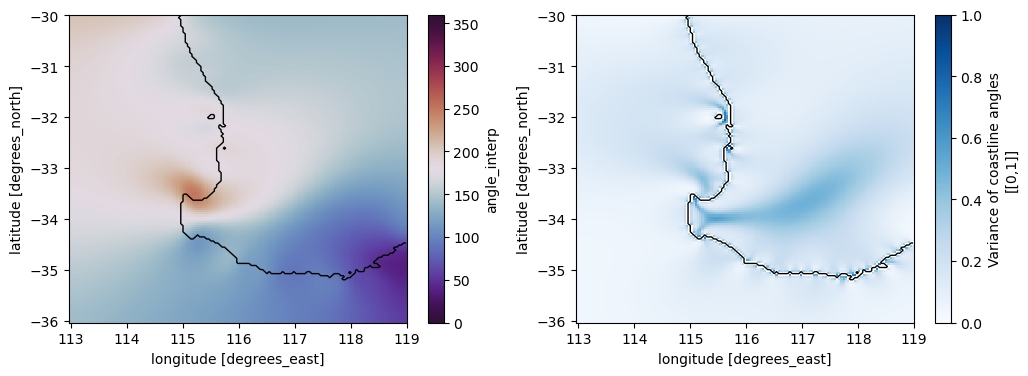

In [5]:
plt.figure(figsize=[12,4])

#Plot the coastline orientation angles. We use the angle_interp variable to have continuous values at the coastline. The angle variable is not defined at the coastline.
plt.subplot(1,2,1)
angle_ds.angle_interp.plot(
    cmap="twilight_shifted",vmin=0,vmax=360)

#Overlay the land sea mask from the model
lsm.plot.contour(levels=[0.5], colors='k', linewidths=1)

#Plot coastline angle variance. Note this is not defined at the coastline
plt.subplot(1,2,2)
angle_ds.variance.plot(
    cmap="Blues", vmin=0, vmax=1)
lsm.plot.contour(levels=[0.5], colors='k', linewidths=1)

We can now use these coastline angles to rotate the u and v winds to be coastline-relative. We use the `rotate_wind` function to compute `vprime` (the cross-shore wind component).

In [6]:
#Calculate along-shore (uprime) and cross-shore (vprime) wind components by rotating the u and v wind components to align with the coastline orientation angles
uprime, vprime = rotate_wind(
    u=barra_uas.uas,
    v=barra_vas.vas,
    theta=angle_ds.angle_interp
    )

Let's have a look at `vprime` for a single time step during the early afternoon in Perth (06:00 UTC). The shading in the plot below indicates the `vprime` component, with green (positive) values representing onshore flow (including related to sea breezes). On the west-facing coastline, you can see a sharp gradient in `vprime` over land representing the sea breeze front, and positive values extending some distance offshore driven by the land-sea temperature difference. A similar front is present over the south-facing coastline.

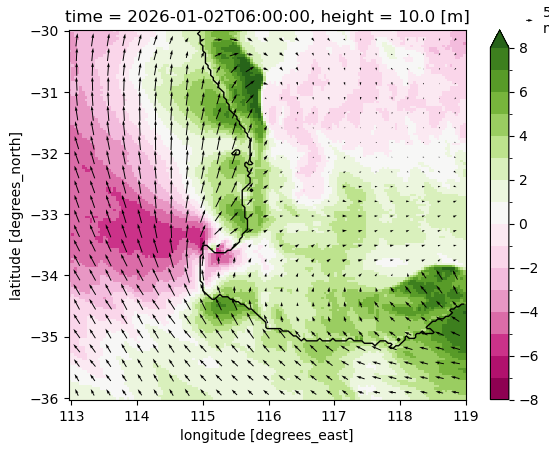

In [7]:
#Plot the cross-shore wind component (vprime) at a specific time, overlaying the land-sea mask and wind vectors
vprime.sel(time="2026-01-02 06:00").plot(levels=np.arange(-8, 9, 1), cmap="PiYG")
lsm.plot.contour(levels=[0.5], colors='k', linewidths=1)
barra_wind.sel(time="2026-01-02 06:00").coarsen({"lat":6,"lon":6}, boundary="trim").mean().plot.quiver(x="lon", y="lat", u="u", v="v", scale=300, color="k");

Now let's look at the average `vprime` component during the early afternoon (06:00 UTC) for the entire month. The `vprime` component is maximised along the coast due to the sea breeze, which is driven by differential heating across the coastline and associated pressure gradient.

Note that this only uses one month of data, and is likely not representative of the sea breeze climate.

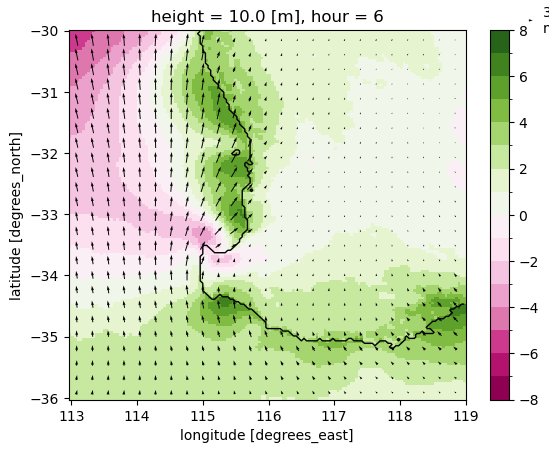

In [8]:
#Plot the mean cross-shore wind component (vprime) at 6 UTC across all days, overlaying the land-sea mask and average wind vectors
vprime.groupby("time.hour").mean(dim="time").sel(hour=6).plot(levels=np.arange(-8, 9, 1), cmap="PiYG")
lsm.plot.contour(levels=[0.5], colors='k', linewidths=1)
barra_wind.groupby("time.hour").mean(dim="time").sel(hour=6).coarsen({"lat":6,"lon":6}, boundary="trim").mean().plot.quiver(x="lon", y="lat", u="u", v="v", scale=300, color="k")

We can look at the spatial-diurnal evolution of the sea breeze by averaging the `vprime` component at different distances from the coast at different times of the day. The below plot shows that onshore winds (the sea breeze) start at around 02:00 UTC on the coastline, strengthen during the day, and move onshore and offshore.

Text(0.5, 0, 'Distance from Coastline (km)\nNegative = Ocean, Positive = Land')

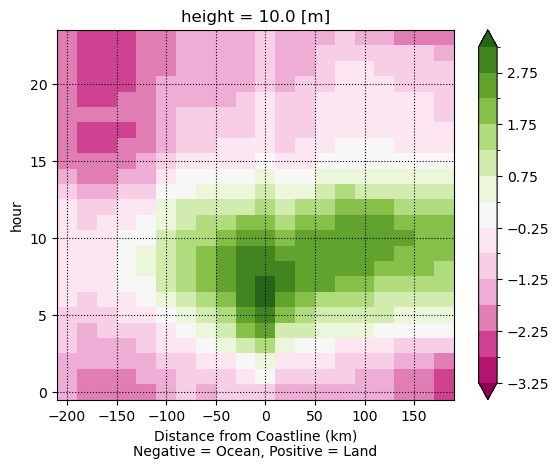

In [9]:
#Calculate the signed distance from the coastline, where land points have positive distances and ocean points have negative distances
dist = xr.where(lsm,angle_ds.min_coast_dist,-angle_ds.min_coast_dist).compute()

#Plot the mean cross-shore wind component (vprime) as a function of distance from the coastline and time of day, using 20 km bins for distance
vprime.groupby("time.hour").mean().groupby_bins(dist, bins=np.arange(-210, 210, 20)).mean().plot.pcolormesh(x="group_bins",y="hour",cmap="PiYG", levels=np.arange(-3.25, 3.75, 0.5),extend="both")
plt.gca().grid(ls=":",color="k")

plt.xlabel("Distance from Coastline (km)\nNegative = Ocean, Positive = Land")

### Defining sea breeze fronts using winds and moisture

We can also attempt to define sea breezes as discrete "objects", based on the identification of fronts between moist maritime air and dry inland air. The 2d frontogenesis diagnostic is used here to diagnose fronts using moisture and winds. It is defined as the growth rate in the gradient of a scalar quantity (see [Brown et al. 2026](https://gmd.copernicus.org/articles/19/933/2026/#section3), Section 3.2.2).

The `kinematic_frontogenesis` function is used here to calculate frontogenesis (`F`) based on the BARRA surface winds and specific humidity.

In [10]:
#Calculate the kinematic frontogenesis function using the BARRA datasets for specific humidity, u wind component, and v wind component
F=kinematic_frontogenesis(
    q=barra_hus.huss,
    u=barra_uas.uas,
    v=barra_vas.vas
)

Plotting a snapshot of `F` for the early afternoon, we can see that the frontogenesis diagnostic identifies the sea breeze front along both coastlines. 

Note that there can also be regions of high `F` values for other reasons, including frictional convergence along the coast (as in some coastlines in the plot below), topographic effects, dry lines and synoptic-scale frontal systems. For a further discussion of this, as well as methods to remove these other fronts ("filtering"), please see [Brown et al. (2026)](https://gmd.copernicus.org/articles/19/933/2026/).

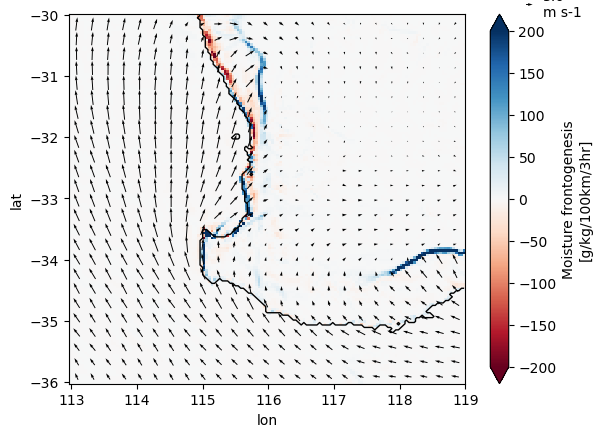

In [12]:
#Plot the kinematic frontogenesis function at a specific time, overlaying the land-sea mask and wind vectors
F.F.sel(time="2026-01-02 06:00").plot(cmap="RdBu",vmin=-200,vmax=200)
barra_wind.sel(time="2026-01-02 06:00").coarsen({"lat":6,"lon":6}, boundary="trim").mean().plot.quiver(x="lon", y="lat", u="u", v="v", scale=300, color="k")
lsm.plot.contour(levels=[0.5], colors='k', linewidths=1)

---

## Learn more

- A full description of methods, including for calculating coast-relative winds and sea breeze "objects", can be found here:  https://gmd.copernicus.org/articles/19/933/2026/

- The [sea_breeze](https://github.com/andrewbrown31/sea_breeze) code repository includes further information on the functions used here, as well as more [example notebooks](https://github.com/andrewbrown31/sea_breeze/tree/main/example_notebooks) on sea breeze and convergence line object identification